# Regional Sales Analysis

Dataset:-  Is nothing but a regional Saless analysis dataset

Problem Statement: Sales teams often lack a clear, data-driven understanding of regional performance making it difficult to identify growth opportunities and optimize resources. This project aims to analyse and visualize the regional sales to uncover trends, evaluate profitability and support decision making.

Goal:- Leverage 5 Years of historical data to pinpoint growth levers and optimize startegy

Steps followed:-

1. Business Objective: core problem discussed above and business outcomes (goal)
2. Collection and consolidating data :- data from kaggle
3. Data laoding and Initial Steps to Understand data
4. Pre-processing and Cleaning
5. EDA (Exploratory Data Analysis)
6. Dashboarding and Recommendation using Power BI

Step 5 and Step 6 are collectively an Iterative Process ( we build dashboards after that or Pass data using predictive modeling)



Data Understanding :-  Regional Sales Dataset.xlsx

Entity Realtionship Diagram in Github

Order Number : Primary Key , Cusomter Index (Primary Key in Customers)
Foreign Key: Customer Name Index (connected with Customers)
Statecode  is primary key in State regions and foreign key in regions
regions ID is primary key in sales order table

product description index (foreign key in sales order) and primary key in products
Product name is conneted with product index using product code (somehow realted to 2017 index) (not primary key)

Warehouse code is not available in any other realtional table so skipping it.

They always have a **1 to N realtionship**.


# Satement Before start

A dummy companies 2014-2018 sales data to identify key revenue and profit drivers across products, channels, and regions to uncover seasonal trends and outiers, and align performance against budgets. Use these insights to optimize pricing , promotions and market expansions for sustainable growth and reduced concentration risk.

Importation Librarires and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading datset

sheets = pd.read_excel('/content/Regional Sales Dataset.xlsx',sheet_name= None)




In [3]:
# Assign dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

In [4]:
df_state_reg_1 = sheets['State Regions']


Data Profiling or Intital inspection of data

In [5]:
df_sales.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [6]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  float64       
dtypes: d

In [7]:
print("df_sales shape: " , (df_sales.shape))
print("df_customers shape: " , (df_customers.shape))
print("df_products shape: " , (df_products.shape))
print("df_regions shape: " , (df_regions.shape))
print("df_state_reg shape: " , (df_state_reg.shape))
print("df_budgets shape: " , (df_budgets.shape))


df_sales shape:  (64104, 12)
df_customers shape:  (175, 2)
df_products shape:  (30, 2)
df_regions shape:  (994, 15)
df_state_reg shape:  (49, 3)
df_budgets shape:  (30, 2)


In [8]:
 df_customers.head(5)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [9]:
df_products.head(5)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [10]:
df_regions.head(5)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [11]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [12]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


Changing the headers for State Regions as they are alrady given as column 1, 2 and 3

Converted second row as header

In [13]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop=True)

df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [14]:
new_header = df_state_reg_1.iloc[0]
df_state_reg_1.columns = new_header
df_state_reg_1 = df_state_reg_1[1:].reset_index(drop=True)

df_state_reg_1.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


Starting the process

Simple NUll value check

In [15]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [16]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [17]:
df_products.isnull().sum()

,0
Index,0
Product Name,0


In [18]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [19]:
df_state_reg.isnull().sum()

,0
0,
State Code,0
State,0
Region,0


In [20]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


Found No Null values and Now data cleaning and wrangling

merging tables

In [21]:
df_sales.head(1)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343


In [22]:
# Merge with customers
df = df_sales.merge(
    df_customers,
    how='left',
    left_on = 'Customer Name Index',
    right_on= 'Customer Index'
)

In [23]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [24]:
# Merge with Products

df = df.merge(
    df_products,
    how='left',
    left_on = 'Product Description Index',
    right_on= 'Index'
)

In [25]:
df.head(5)


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [26]:
# Merge with Regions

df = df.merge(
    df_regions,
    how='left',
    left_on = 'Delivery Region Index',
    right_on= 'id'
)

In [27]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [28]:
# Merge with State regions

df = df.merge(
    df_state_reg_1[['State Code','Region']],
    how='left',
    left_on = 'state_code',
    right_on= 'State Code'
)

In [29]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [30]:
# Merge with 2017 budget

df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

In [31]:
df.to_csv('Regional_data.csv')

Now we  see from which columns do we have to get rid of from our new CSV file

Customer Index
index
id
State Code

these are repeatative columns hence geeeting rid of these


In [32]:
#Customer Index
#Index
#id
#State Code

# Cleaning redundant columns

cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df = df.drop(columns= cols_to_drop, errors='ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [33]:
# convert all columns to lower case for consistency and easier access

df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

Getting rid of some columns that we dont need:

1. Customer Name Index
2. Currency code : All in USD (un-necessary data)
3. Delivery Region Index
4. Product Desripton index
5. Time-zone
6. type

In [34]:
#keep the important columns and delete the columns we dont need
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [35]:
df = df[cols_to_keep]

We now stick to this final data for further analysis

and we see that we joined data from 2017 budget to the data frame on product name and it gives the same budget for each procut name even thogh it is dated for 2014, so what we now do it mark all non 2017 budget as blanked out

In [36]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [37]:
# rename the columns

df = df.rename(columns={
    'ordernumber': 'order_number',
    'orderdate': 'order_date',
    'customer names': 'customer_name',
    'product name': 'product_name',
    'order quantity': 'order_quantity',
    'unit price': 'unit_price',
    'line total': 'revenue',
    'total unit cost': 'cost',
    'state':'state_name',
    'latitude': 'lat',
    'longitude': 'long',
    '2017 budgets': 'budget'
})

df.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,county,state_name,region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [38]:
from pandas._libs.missing import NA
# blank out bidgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017,'budget'] = pd.NA

# line total is revenue
df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [39]:
df[['order_date','product_name','revenue','budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [40]:
# final data set ready for EDA process
df.to_csv('Final_sales.csv')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_name   64104 non-null  object        
 3   channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state_code      64104 non-null  object        
 10  county          64104 non-null  object        
 11  state_name      64104 non-null  object        
 12  region          64104 non-null  object        
 13  lat             64104 non-null  float64       
 14  long            64104 non-null  float64       
 15  bu

In [42]:
#Filter the dataset to include only the records from 2017

df_2017 = df[df['order_date'].dt.year == 2017]

In [43]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
order_quantity,0
unit_price,0
revenue,0
cost,0
state_code,0


In [44]:
df_2017.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,county,state_name,region,lat,long,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


#Exploratory Data Analysis

###Feature Engineering


Creating new feature and then EDA

In [46]:
df.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,county,state_name,region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN


In [47]:
df['total_cost'] = df['order_quantity'] * df['cost']

In [49]:
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100

In [50]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,county,state_name,region,lat,long,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


Intital Inspection : Sales consistently cycles between 23-26 Millions and there 4-5 outliers, Downward spiked around the start of the year

in 2017 a sharp drop (very clear outlier)


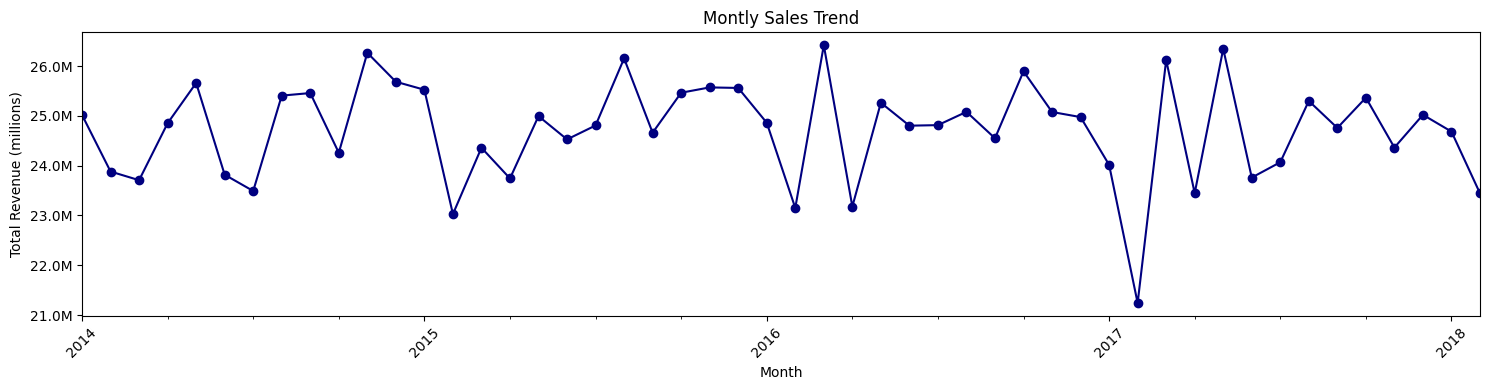

In [52]:
df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))

monthly_sales.plot(marker='o',color='navy')

from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos:f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Montly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Deduction:

even though the upper graph shows that there are downward spkies in the start of the year, the lower grpah shows that january (start of the year had the maximum revenue) , this is beacuse the sum total of revenue only in January (for all januaries of 2014-2018) is high, hence january is the highest revenue groosing month in lower graph (for all years)

this trend was also verified manually using the excel sum fuctions and aggregations in the sheet itself for each januaries compared with other months of the years given and it was true.

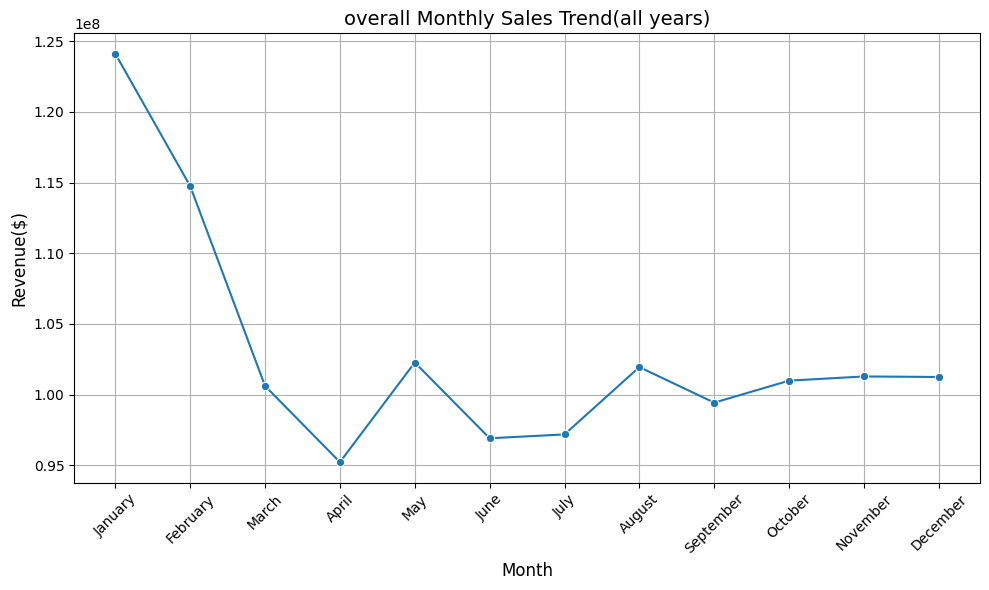

In [54]:
df['order_date'] = pd.to_datetime(df['order_date'])


df['month'] = df['order_date'].dt.strftime('%B')

monthly_trend = df.groupby('month')['revenue'].sum().reset_index()

month_order = ["January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"]
monthly_trend['month'] = pd.Categorical(monthly_trend['month'], categories= month_order, ordered=True)

monthly_trend = monthly_trend.sort_values('month')


plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_trend,x='month',y='revenue',marker='o')

plt.title("overall Monthly Sales Trend(all years)",fontsize=14)

plt.xlabel('Month',fontsize=12)
plt.ylabel('Revenue($)',fontsize=12)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

Now what we do is try to remove 2018 extra 2 months data for january and febuary beacause that data is makinf the aggregate of january revenue higher and it is not correct

In [55]:
df['order_date'] = pd.to_datetime(df['order_date'])

df_new = df[~((df['order_date'].dt.year==2018)& (df['order_date'].dt.month.isin([1,2])))]


Now when we have removed it , the graph states MAY as the new overall highest revenue grosser and hence the data exploration make sense now.

/tmp/ipykernel_6295/651379040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['order_date'] = pd.to_datetime(df['order_date'])
/tmp/ipykernel_6295/651379040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['month'] = df_new['order_date'].dt.strftime('%B')


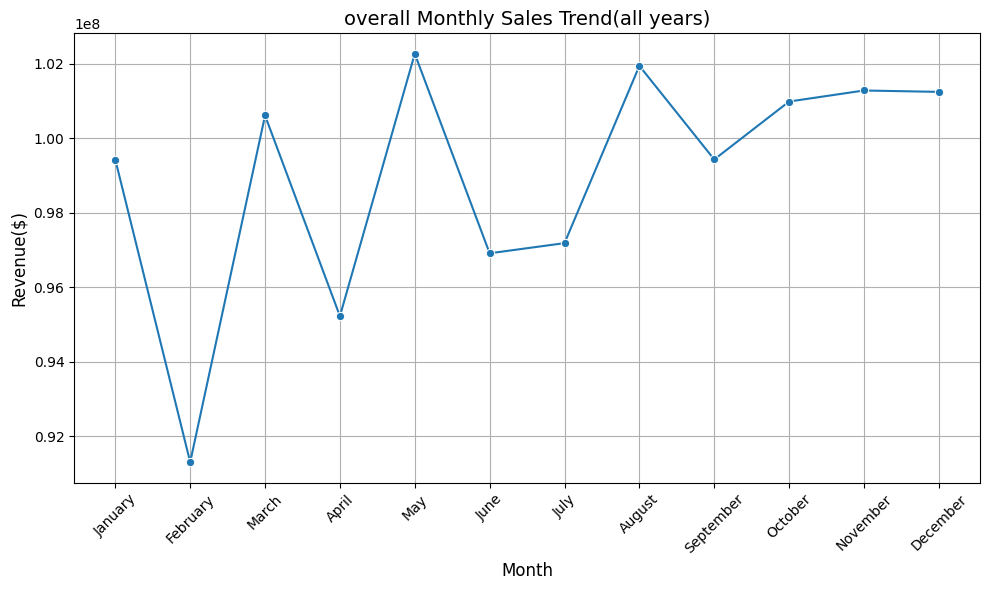

In [56]:
df_new['order_date'] = pd.to_datetime(df['order_date'])


df_new['month'] = df_new['order_date'].dt.strftime('%B')

monthly_trend = df_new.groupby('month')['revenue'].sum().reset_index()

month_order = ["January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"]
monthly_trend['month'] = pd.Categorical(monthly_trend['month'], categories= month_order, ordered=True)

monthly_trend = monthly_trend.sort_values('month')


plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_trend,x='month',y='revenue',marker='o')

plt.title("overall Monthly Sales Trend(all years)",fontsize=14)

plt.xlabel('Month',fontsize=12)
plt.ylabel('Revenue($)',fontsize=12)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

Deduction of graph above: May, followed by August and March highest grossers, no such distinctive pattern or evry two months the revenue score comes down (not distinctive though)

Finding Top 10 products by revenue

In [57]:
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

top_10_products = product_revenue.sort_values(by='revenue', ascending=False).head(10)

labels = top_10_products['product_name'].tolist()
data = top_10_products['revenue'].tolist()

print("Labels for chart:",labels)
print("Data for Chart:",data)

Labels for chart: ['Product 26', 'Product 25', 'Product 13', 'Product 14', 'Product 5', 'Product 15', 'Product 2', 'Product 4', 'Product 1', 'Product 3']
Data for Chart: [112454990.9, 105715762.4, 75190019.7, 72516666.10000001, 68032711.2, 64933726.7, 54976803.1, 54558669.5, 53678832.2, 49935227.300000004]


We have Product 26 as the highest paid product followed by product 25 and then sharp drop for Rpduct 13 followed by product 14

/tmp/ipykernel_6295/1298364768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products,x='product_name',y='revenue', palette='tab10')


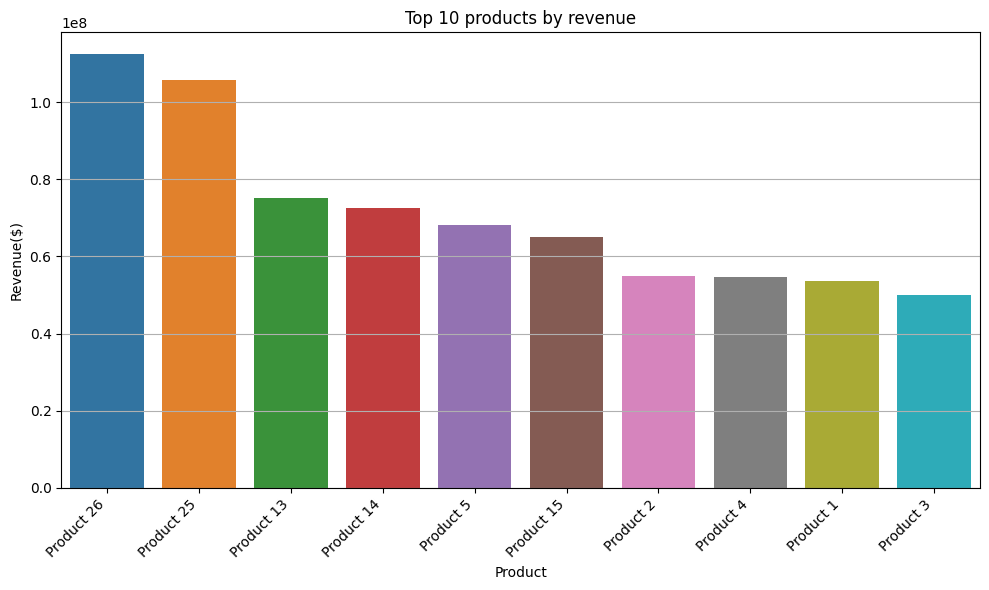

In [59]:
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

top_10_products = product_revenue.sort_values(by='revenue', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_10_products,x='product_name',y='revenue', palette='tab10')
plt.title('Top 10 products by revenue')
plt.xlabel("Product")
plt.ylabel("Revenue($)")
plt.xticks(rotation=45,ha='right')

plt.grid(True,axis='y')

plt.tight_layout()

plt.show()

/tmp/ipykernel_6295/954700023.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


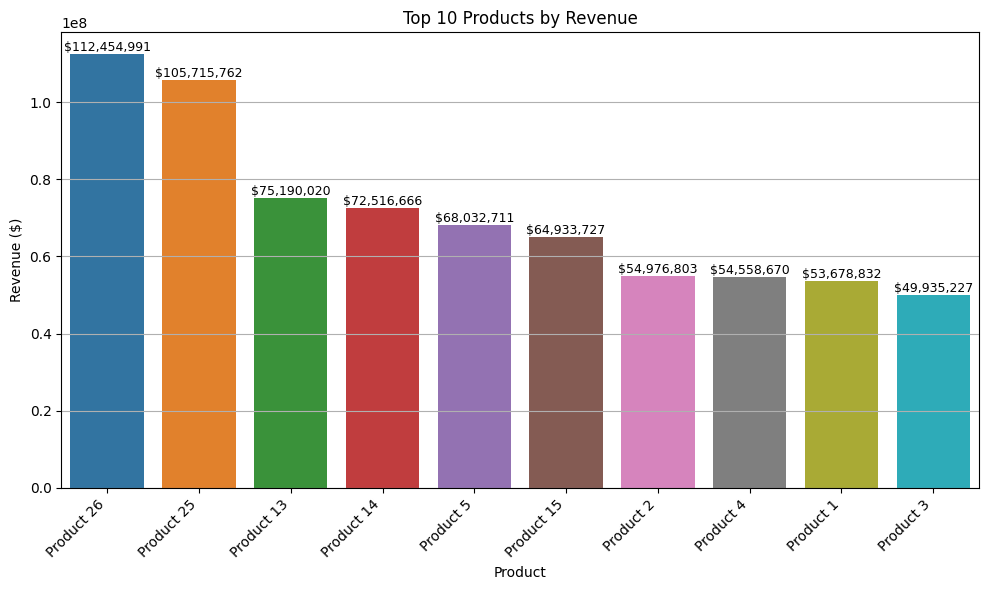

In [60]:
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

top_10_products = product_revenue.sort_values(by='revenue',ascending=False).head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_10_products,x='product_name', y='revenue',palette='tab10')
plt.title('Top 10 Products by Revenue')
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')

#Labels

for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

For bottom 10 now

In [63]:
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

bottom_10_products = product_revenue.sort_values(by='revenue', ascending=True).head(10)

labels = bottom_10_products['product_name'].tolist()
data = bottom_10_products['revenue'].tolist()

print("Labels for chart:",labels)
print("Data for Chart:",data)

Labels for chart: ['Product 9', 'Product 24', 'Product 29', 'Product 22', 'Product 7', 'Product 10', 'Product 27', 'Product 30', 'Product 23', 'Product 21']
Data for Chart: [13834836.700000001, 13904590.4, 14651251.8, 14940289.8, 16379275.6, 16702811.9, 17607358.8, 17610387.2, 18316473.400000002, 18354006.8]


product ( is the lowest followed by product 24 etc.

/tmp/ipykernel_6295/1864570861.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bottom_10_products,x='product_name', y='revenue',palette='tab10')


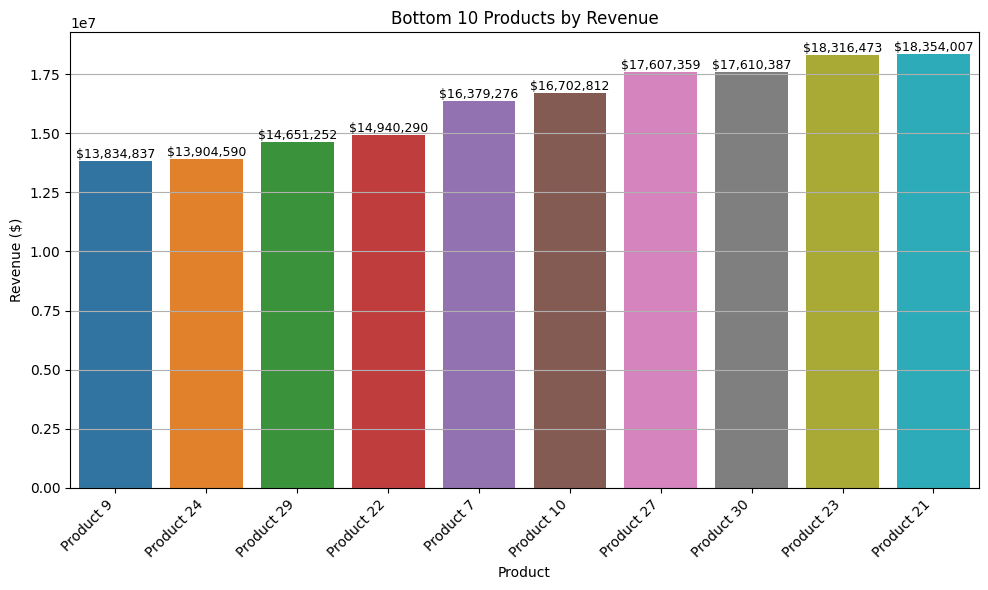

In [64]:
product_revenue = df_new.groupby('product_name')['revenue'].sum().reset_index()

bottom_10_products = product_revenue.sort_values(by='revenue',ascending=True).head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=bottom_10_products,x='product_name', y='revenue',palette='tab10')
plt.title('Bottom 10 Products by Revenue')
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')

#Labels

for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Sales by channel chart

Wholesales(54.1%) is the top percentage followed by distributor and Export

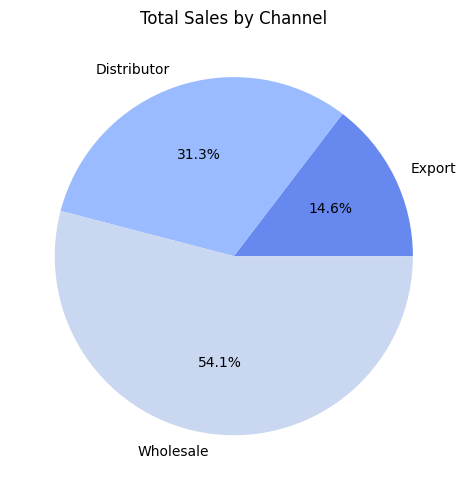

In [68]:
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5,5))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by Channel')

plt.tight_layout()
plt.show()

#Average Order Value (AOV) Distribution


Graph is not uniformly Distributed, it is certain type of skewness in it, right skewed graph, most orders clustering between 20-100K and maximum is around 50-60K , long tail, large order share only a small revenue most of the things are in the first half

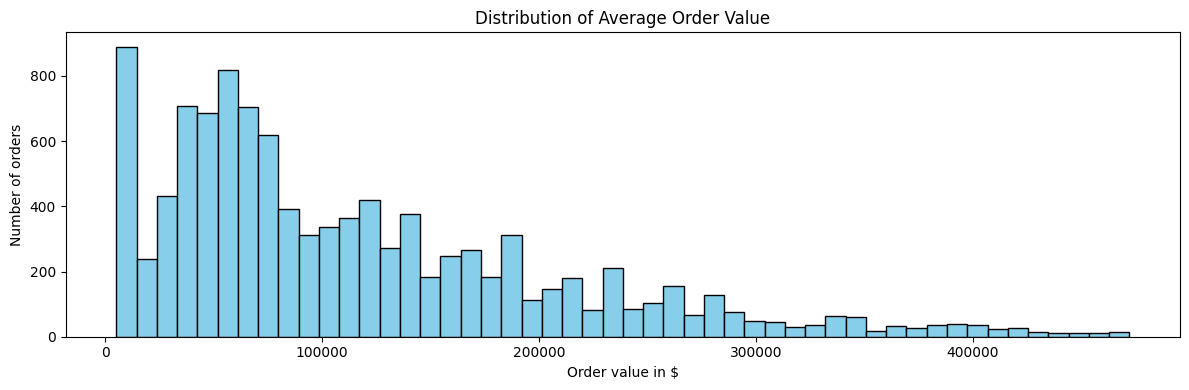

In [71]:
#Average Order Value (AOV) Distribution

aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12,4))

plt.hist(
    aov,
    bins=50,
    color = 'skyblue',
    edgecolor= 'black'
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order value in $')
plt.ylabel('Number of orders')

plt.tight_layout()

plt.show()

####Unit Price Distribution per Product
#### Top 10 states by revenue and order count
#### Average profit Margin by channel
#### Top and Bottom 10 Customers by revenue
#### Customer segmentation: Revenue vs Profit Margin
#### Correlation heatmap

In [72]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,...,state_name,region,lat,long,budget,total_cost,profit,profit_margin_pct,order_month,month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,2014-01,January
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,2014-01,January
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,2014-01,January
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,2014-01,January
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,2014-01,January


/tmp/ipykernel_6295/4143342782.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_10,x='product_name',y='unit_price',palette='tab10')


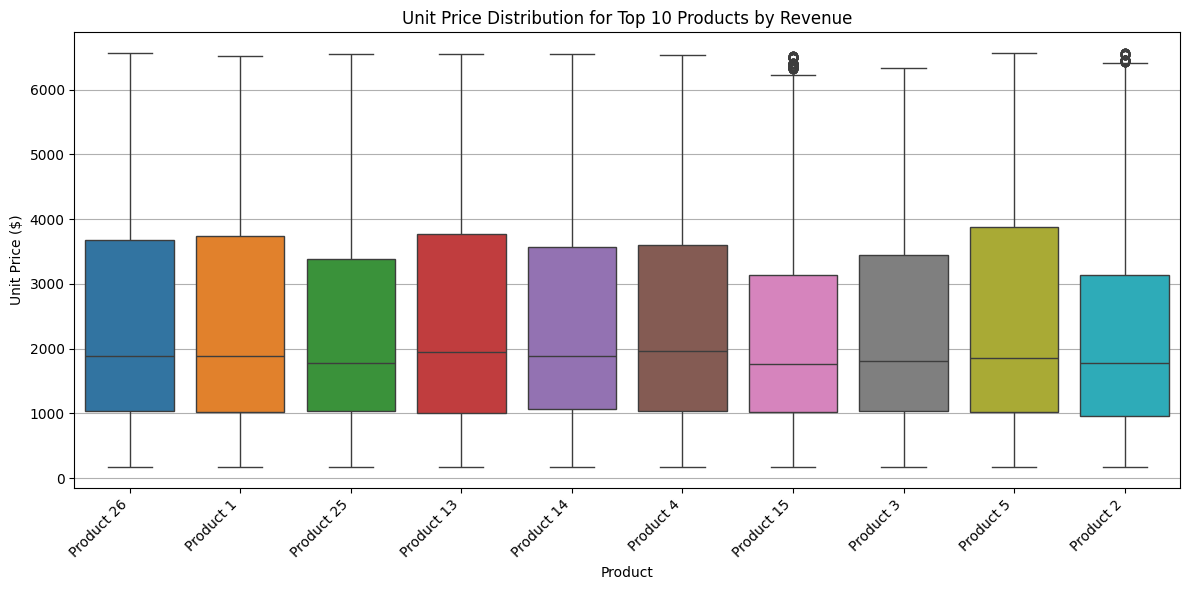

In [73]:
# Unit Price Distribution per Product

product_revenue = df.groupby('product_name')['revenue'].sum().reset_index()

top_10_products = product_revenue.sort_values(by='revenue',ascending=False).head(10)['product_name'].tolist()

df_top_10 = df[df['product_name'].isin(top_10_products)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_10,x='product_name',y='unit_price',palette='tab10')

plt.title('Unit Price Distribution for Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Unit Price ($)')

plt.xticks(rotation=45,ha='right')

plt.grid(True,axis='y')

plt.tight_layout()
plt.show()

Product 8,17,27,20,28 show high-end revenue spikes- well above their upper whiskers-likely due to bulk orders, special edition releases or premium bundles that temporarily inflate earnings



/tmp/ipykernel_6295/3949048113.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


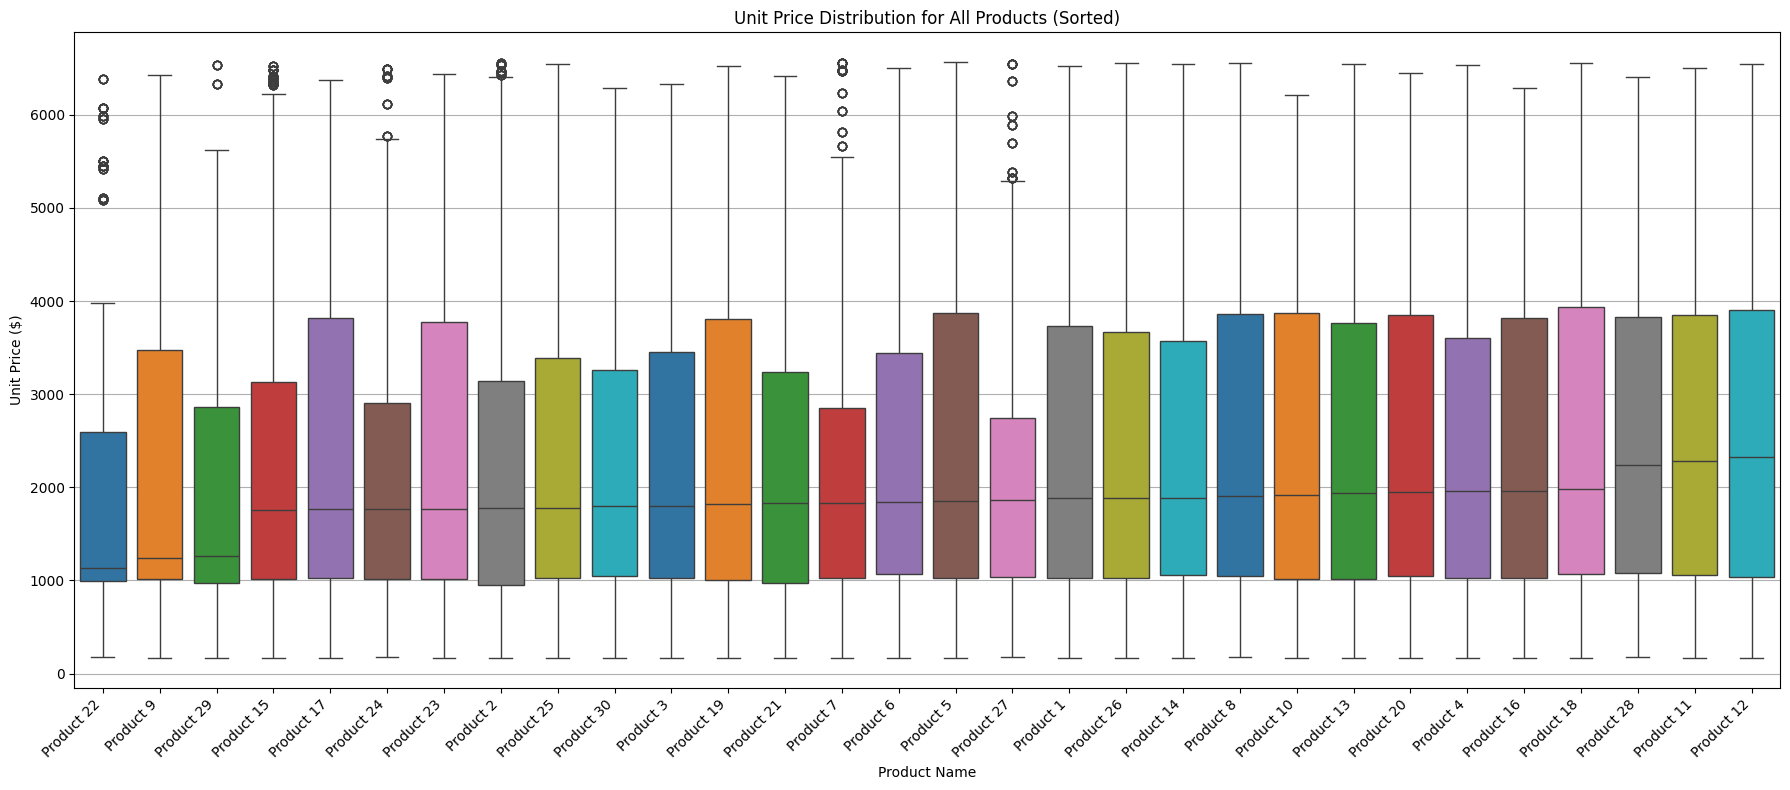

In [89]:
#For all Products

order = df.groupby('product_name')['unit_price'].median().sort_values().index

plt.figure(figsize=(18,8))

ax = sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    order=order,
    palette='tab10'
)

plt.title('Unit Price Distribution for All Products (Sorted)')
plt.xlabel('Product Name')
plt.ylabel('Unit Price ($)')

plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [76]:
# Top 10 states by revenue and order count


state_stats = df.groupby('state_name').agg(
    revenue=('revenue', 'sum'),
    order_count=('order_number', 'count')
).reset_index()


California sits on top

/tmp/ipykernel_6295/1559214374.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


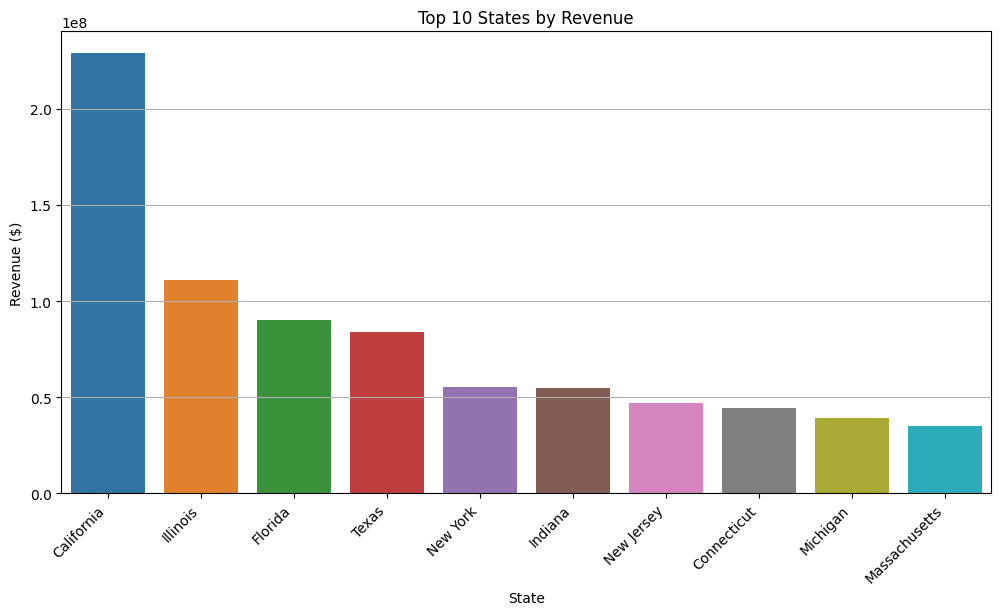

In [75]:
top_10_states = state_stats.sort_values(
    by='revenue',
    ascending=False
).head(10)

# -----------------------------
# 3. Plot: Revenue by state
# -----------------------------
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_10_states,
    x='state_name',
    y='revenue',
    palette='tab10'
)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_6295/194040545.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


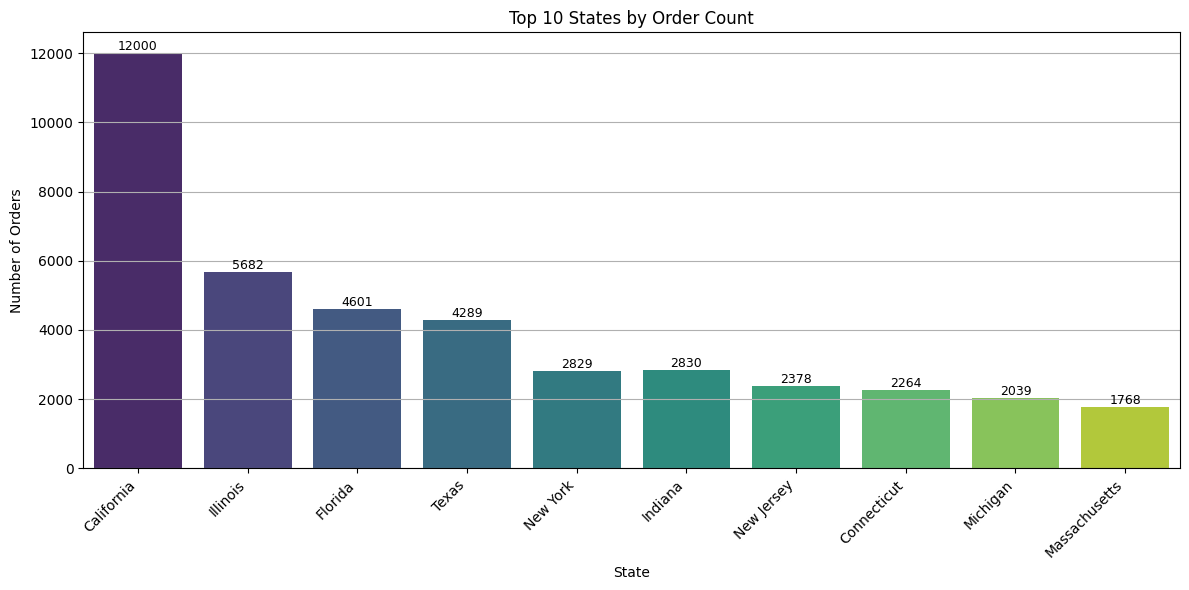

In [77]:
# Labels
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#Order count by state

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_10_states,
    x='state_name',
    y='order_count',
    palette='viridis'
)

plt.title('Top 10 States by Order Count')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')

# Labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Export is on top

/tmp/ipykernel_6295/1752127986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


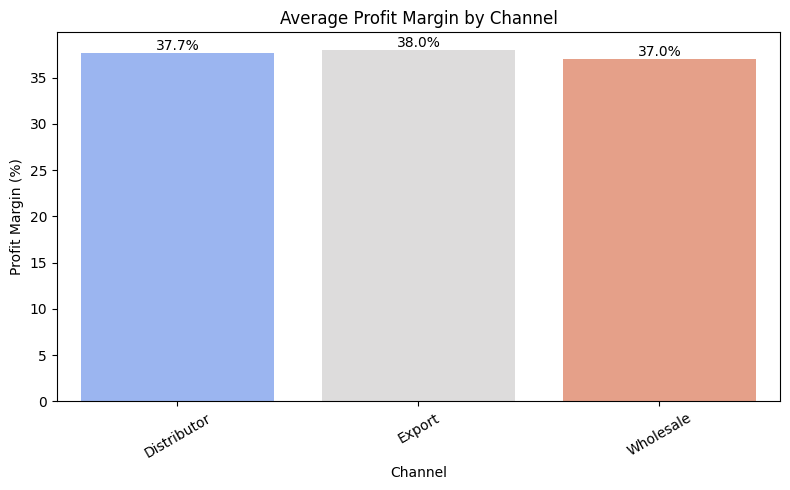

In [78]:
#Average Profit Margin by Channel
channel_stats = df.groupby('channel').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum')
).reset_index()

channel_stats['profit_margin'] = (
    channel_stats['profit'] / channel_stats['revenue']
) * 100

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=channel_stats,
    x='channel',
    y='profit_margin',
    palette='coolwarm'
)

plt.title('Average Profit Margin by Channel')
plt.xlabel('Channel')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Aibox is top

BB17 is bottom

In [80]:
#Top & Bottom 10 Customers by Revenue

customer_revenue = df.groupby('customer_name')['revenue'].sum().reset_index()

top_10 = customer_revenue.sort_values(by='revenue', ascending=False).head(10)
bottom_10 = customer_revenue.sort_values(by='revenue', ascending=True).head(10)

/tmp/ipykernel_6295/620922489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


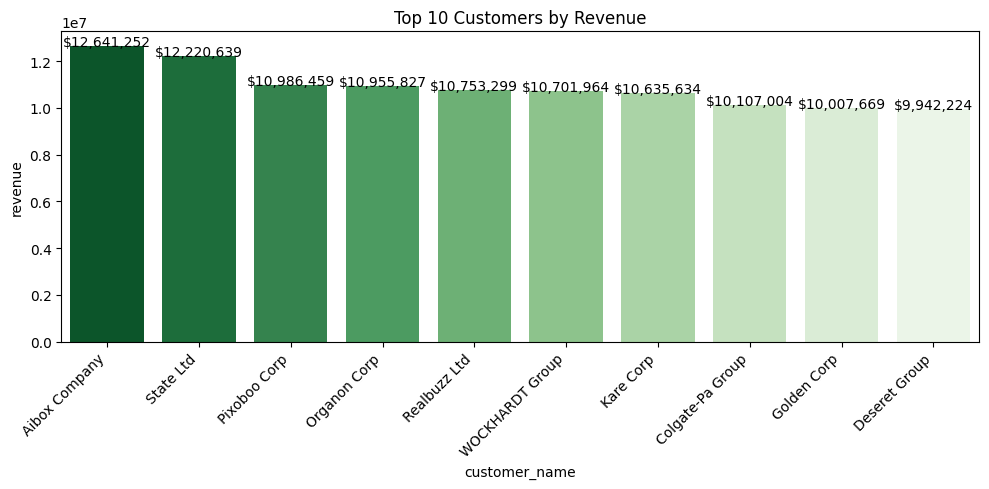

In [81]:
#Top 10
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_10,
    x='customer_name',
    y='revenue',
    palette='Greens_r'
)

plt.title('Top 10 Customers by Revenue')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6295/1533478277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


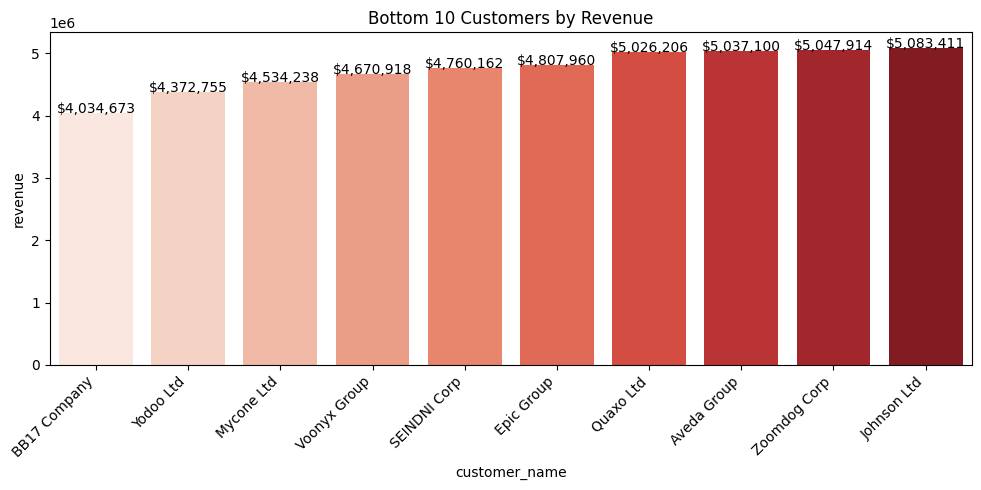

In [82]:
#Bottom 10
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=bottom_10,
    x='customer_name',
    y='revenue',
    palette='Reds'
)

plt.title('Bottom 10 Customers by Revenue')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center')

plt.tight_layout()
plt.show()

Insights:

Extreme right has the cutomers with greater than 10Million USD revenue(Average profit Margin), some customers betwene 6-8 have highes progit margin (only some of them)

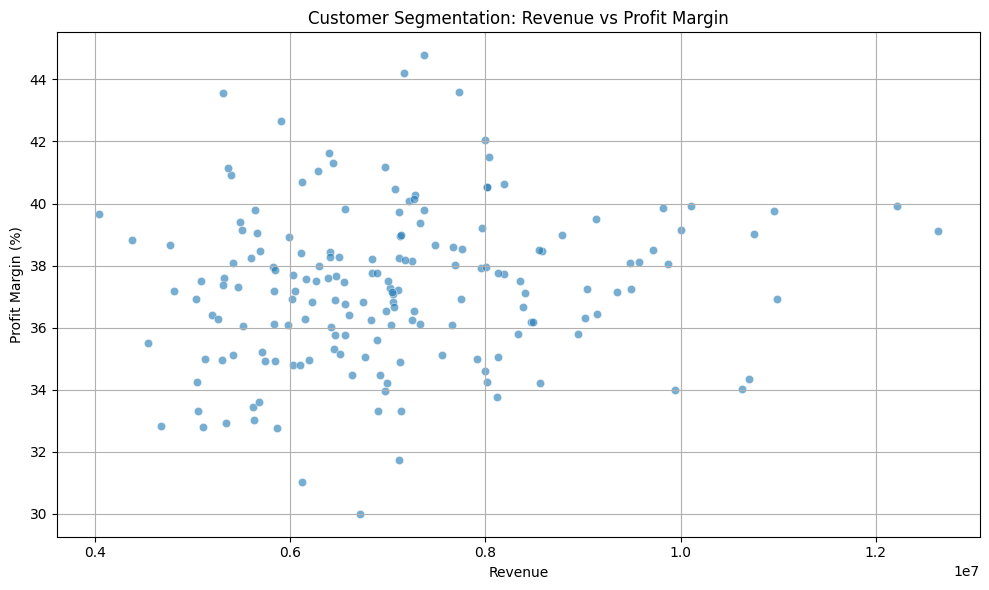

In [85]:
#Customer Segmentation: Revenue vs Profit Margin

customer_stats = df.groupby('customer_name').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum')
).reset_index()

customer_stats['profit_margin'] = (
    customer_stats['profit'] / customer_stats['revenue']
) * 100

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_stats,
    x='revenue',
    y='profit_margin',
    alpha=0.6
)

plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Revenue')
plt.ylabel('Profit Margin (%)')

plt.grid(True)
plt.tight_layout()
plt.show()

Unit_price and revue , profit and revenue (highly correlated)

unitprice vs profit (high correlation)


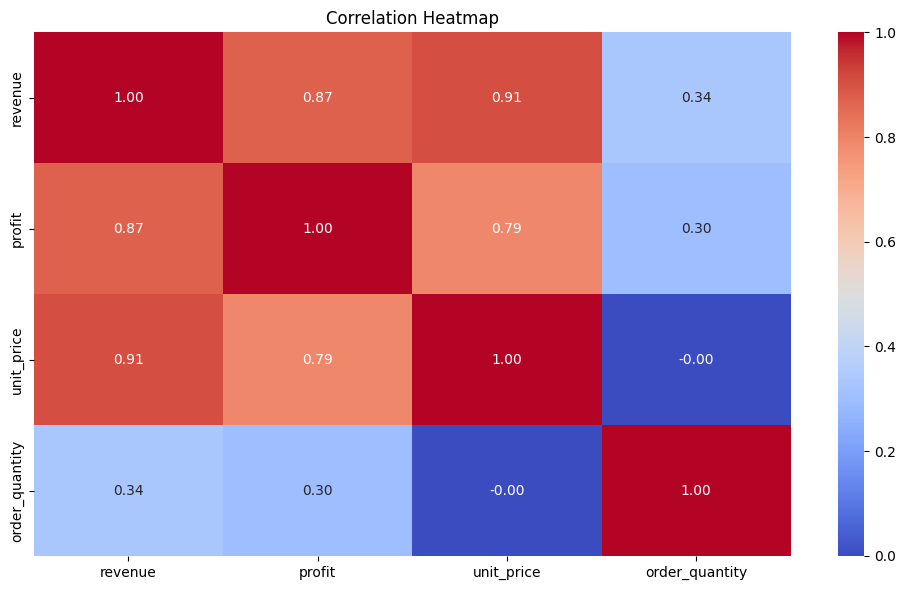

In [87]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

corr = df[['revenue', 'profit', 'unit_price', 'order_quantity']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Channels Distribution: 54% Wholesale, 31% Distribution, 15% Exports

Monthly Revenue Cycle: May peaks